# EDA: Titanic

Анализ сырых `train.csv` и `test.csv`. Графики описывают данные и помогают сформулировать гипотезы. Для моделей медианы, категории и границы бинов обучаются только на train-части каждого CV-фолда.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
root = Path.cwd()
if not (root / "data/titanic/raw/train.csv").exists(): root = root.parent
train = pd.read_csv(root / "data/titanic/raw/train.csv")
test = pd.read_csv(root / "data/titanic/raw/test.csv")
print("Train:", train.shape, "Test:", test.shape)
print("Типы полей train:")
print(train.dtypes.to_string())
print("Полные дубликаты в train:", train.duplicated().sum())


Train: (891, 12) Test: (418, 11)
Типы полей train:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Полные дубликаты в train: 0


## 1. Полнота данных

В train у `Age` нет **177 значений (19,9%)**, у `Cabin` — **687 (77,1%)**, у `Embarked` — **2**. В test: `Age` — **86 (20,6%)**, `Cabin` — **327 (78,2%)**, `Fare` — **1**. `Cabin` трудно использовать как полную категорию; индикатор наличия каюты можно проверить. Заполнение пропусков перед CV приведёт к утечке.


          train_n  train_pct  test_n  test_pct
Age           177       19.9    86.0      20.6
Cabin         687       77.1   327.0      78.2
Embarked        2        0.2     0.0       0.0
Fare            0        0.0     1.0       0.2


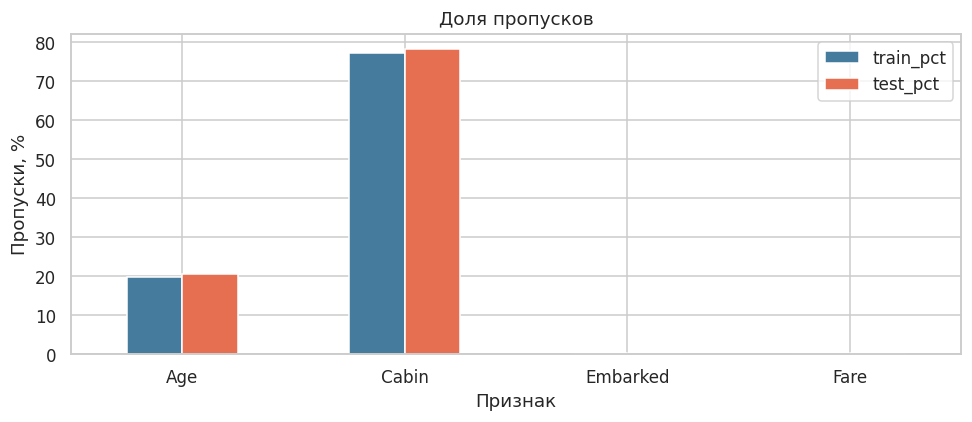

In [2]:
missing = pd.DataFrame({"train_n":train.isna().sum(), "train_pct":train.isna().mean()*100,
                        "test_n":test.isna().sum(), "test_pct":test.isna().mean()*100}).fillna(0)
print(missing.loc[(missing[["train_n","test_n"]]>0).any(axis=1)].round(1).to_string())
p=missing.loc[missing[["train_pct","test_pct"]].max(axis=1)>0,["train_pct","test_pct"]]
ax=p.plot.bar(figsize=(9,4),color=["#457b9d","#e76f51"])
ax.set(title="Доля пропусков",xlabel="Признак",ylabel="Пропуски, %")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 2. Баланс классов

Выжили **342 из 891 пассажира (38,4%)**, не выжили 549. Для валидации нужен стратифицированный split. Основная метрика проекта — F1; accuracy стоит смотреть дополнительно.


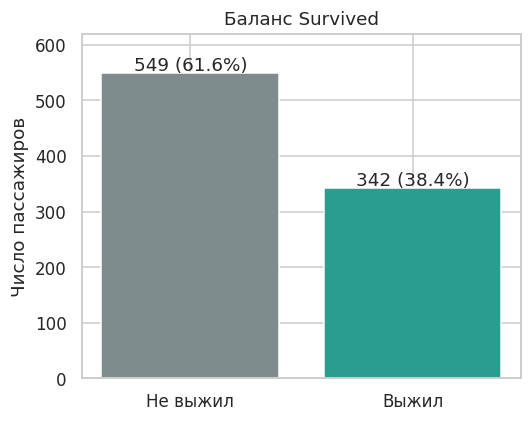

In [3]:
counts=train.Survived.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(5,4))
bars=ax.bar(["Не выжил","Выжил"],counts,color=["#7f8c8d","#2a9d8f"])
for bar,n in zip(bars,counts): ax.text(bar.get_x()+bar.get_width()/2,n+5,f"{n} ({n/len(train):.1%})",ha="center")
ax.set(title="Баланс Survived",ylabel="Число пассажиров",ylim=(0,620))
plt.tight_layout(); plt.show()


## 3. Числовые распределения

Медиана известного `Age` — **28 лет**, максимум — **80**. Для `Fare` медиана **14,45**, среднее **32,20**, максимум **512,33**: распределение имеет длинный правый хвост. `SibSp` и `Parch` чаще равны нулю. Здесь показаны исходные значения без заполнения пропусков.


          Age    Fare   SibSp   Parch
count  714.00  891.00  891.00  891.00
mean    29.70   32.20    0.52    0.38
std     14.53   49.69    1.10    0.81
min      0.42    0.00    0.00    0.00
25%     20.12    7.91    0.00    0.00
50%     28.00   14.45    0.00    0.00
75%     38.00   31.00    1.00    0.00
max     80.00  512.33    8.00    6.00


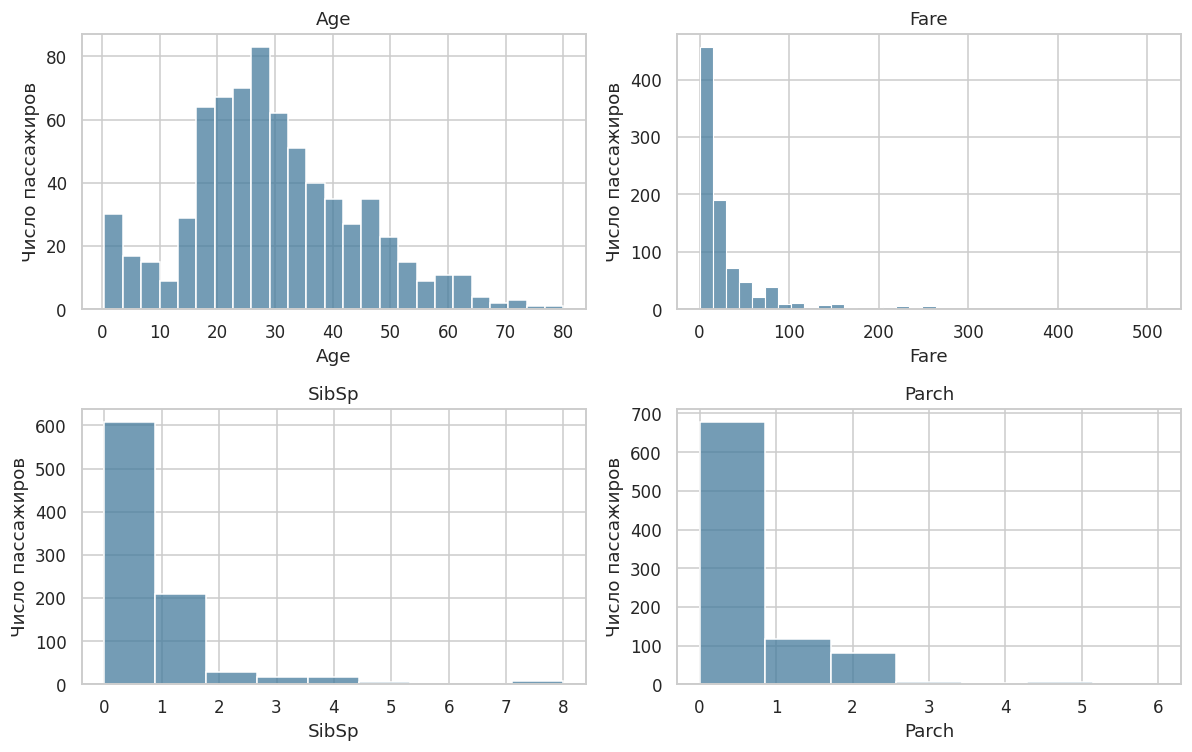

In [4]:
print(train[["Age","Fare","SibSp","Parch"]].describe().round(2).to_string())
fig,axes=plt.subplots(2,2,figsize=(11,7))
for ax,col,bins in zip(axes.flat,["Age","Fare","SibSp","Parch"],[25,35,9,7]):
    sns.histplot(train[col].dropna(),bins=bins,ax=ax,color="#457b9d")
    ax.set(title=col,ylabel="Число пассажиров")
plt.tight_layout(); plt.show()


## 4. Выбросы

По правилу 1,5 × IQR верхняя граница `Fare` — **65,63**; выше неё **116** наблюдений. Для `Age` граница **64,81**, выше неё **11**. Это формальные выбросы, а не доказанные ошибки. Не стоит удалять дорогие билеты и пожилых пассажиров автоматически; `log1p(Fare)` можно сравнить на одинаковых фолдах.


Age: IQR [20.12, 38.00], границы [-6.69, 64.81], вне границ 11
Fare: IQR [7.91, 31.00], границы [-26.72, 65.63], вне границ 116


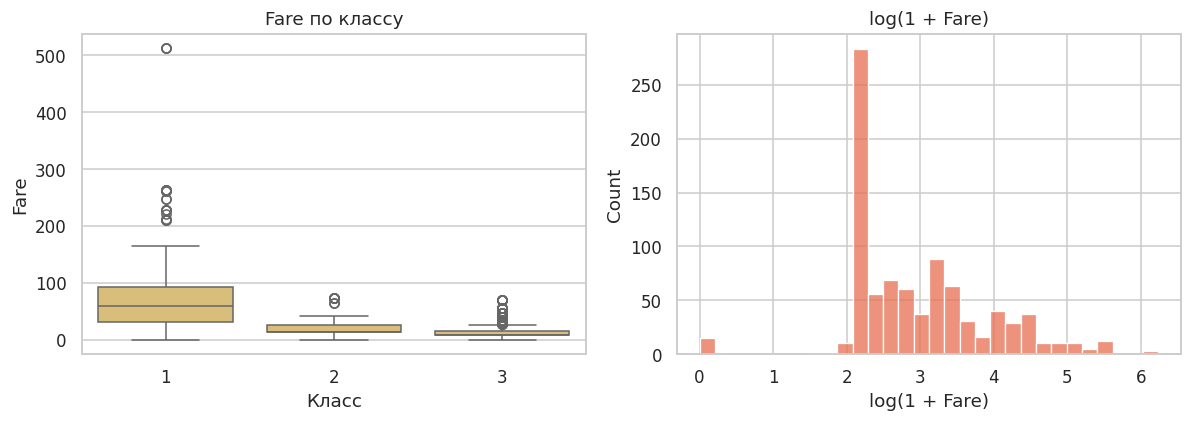

In [5]:
for col in ["Age","Fare"]:
    q1,q3=train[col].quantile([.25,.75]); lo=q1-1.5*(q3-q1); hi=q3+1.5*(q3-q1)
    n=((train[col]<lo)|(train[col]>hi)).sum()
    print(f"{col}: IQR [{q1:.2f}, {q3:.2f}], границы [{lo:.2f}, {hi:.2f}], вне границ {n}")
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.boxplot(data=train,x="Pclass",y="Fare",ax=axes[0],color="#e9c46a")
axes[0].set(title="Fare по классу",xlabel="Класс")
sns.histplot(np.log1p(train.Fare.dropna()),bins=30,ax=axes[1],color="#e76f51")
axes[1].set(title="log(1 + Fare)",xlabel="log(1 + Fare)")
plt.tight_layout(); plt.show()


## 5. Категории и выживаемость

Выжили **74,2%** женщин (314 пассажиров) и **18,9%** мужчин (577). В первом классе выжили **63,0%**, во втором **47,3%**, в третьем **24,2%**. Порт посадки также связан с исходом, но часть различия может объясняться составом пассажиров по классу и полу.


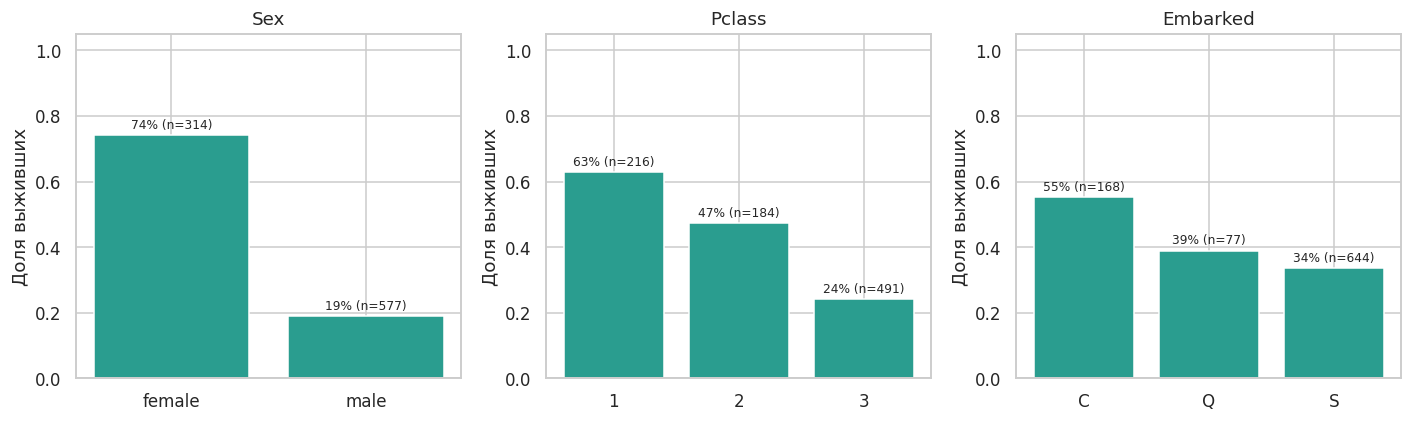

In [6]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,col,order in zip(axes,["Sex","Pclass","Embarked"],[["female","male"],[1,2,3],["C","Q","S"]]):
    t=train.groupby(col)["Survived"].agg(["size","mean"]).reindex(order)
    bars=ax.bar(t.index.astype(str),t["mean"],color="#2a9d8f")
    for bar,n,rate in zip(bars,t["size"],t["mean"]):
        ax.text(bar.get_x()+bar.get_width()/2,rate+.02,f"{rate:.0%} (n={n})",ha="center",fontsize=8)
    ax.set(title=col,ylabel="Доля выживших",ylim=(0,1.05))
plt.tight_layout(); plt.show()


## 6. Пол × класс

Разница по классу сохраняется внутри групп пола. Выжили **96,8%** женщин первого класса и **50,0%** третьего; среди мужчин — **36,9%** и **13,5%**. Признак взаимодействия `Sex × Pclass` — гипотеза для CV, а не готовый вывод о приросте качества.


               size   mean
Pclass Sex                
1      female    94  0.968
       male     122  0.369
2      female    76  0.921
       male     108  0.157
3      female   144  0.500
       male     347  0.135


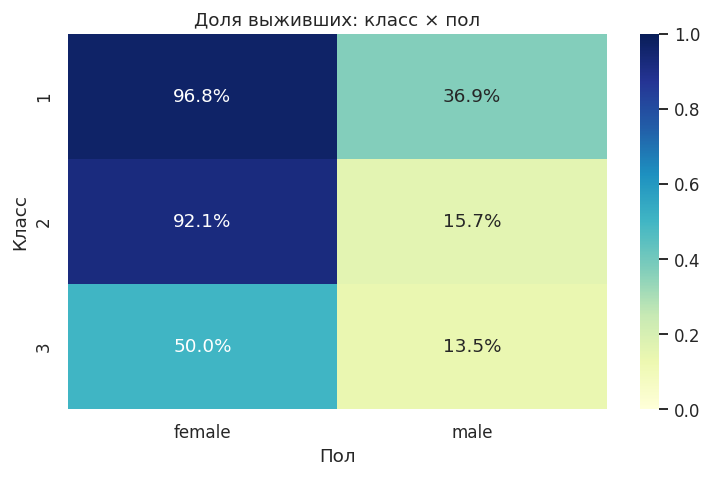

In [7]:
g=train.groupby(["Pclass","Sex"])["Survived"].agg(["size","mean"])
print(g.round(3).to_string())
fig,ax=plt.subplots(figsize=(7,4.5))
sns.heatmap(g["mean"].unstack("Sex"),annot=True,fmt=".1%",cmap="YlGnBu",vmin=0,vmax=1,ax=ax)
ax.set(title="Доля выживших: класс × пол",xlabel="Пол",ylabel="Класс")
plt.tight_layout(); plt.show()


## 7. Возраст и его пропуски

Среди пассажиров с известным возрастом выжили **40,6%**, с пропуском — **29,4%**. Индикатор пропуска `Age` может быть информативным. Гистограмма использует только 714 пассажиров с известным возрастом и не описывает остальных 177.


            size   mean
AgeMissing             
False        714  0.406
True         177  0.294


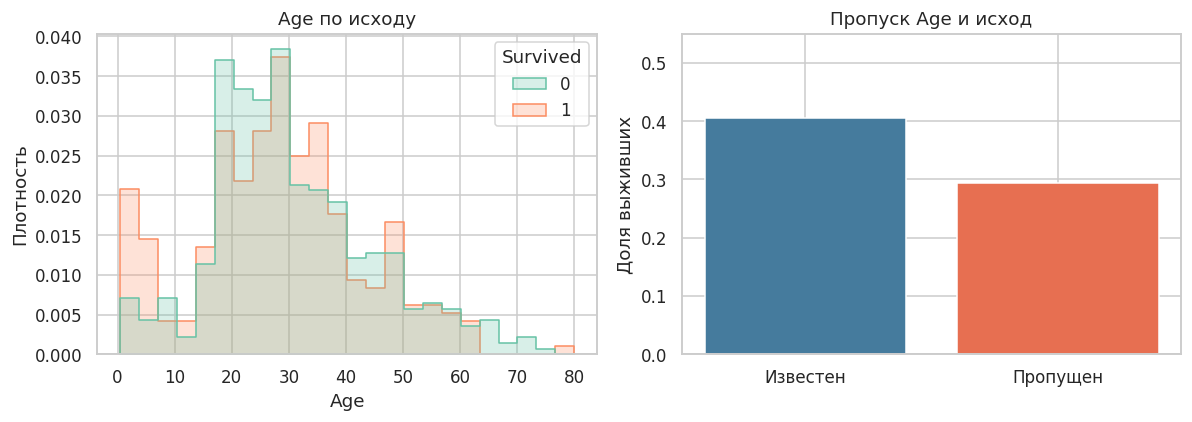

In [8]:
g=train.assign(AgeMissing=train.Age.isna()).groupby("AgeMissing")["Survived"].agg(["size","mean"])
print(g.round(3).to_string())
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.histplot(data=train.dropna(subset=["Age"]),x="Age",hue="Survived",bins=24,
             stat="density",common_norm=False,element="step",ax=axes[0])
axes[0].set(title="Age по исходу",ylabel="Плотность")
axes[1].bar(["Известен","Пропущен"],g["mean"],color=["#457b9d","#e76f51"])
axes[1].set(title="Пропуск Age и исход",ylabel="Доля выживших",ylim=(0,.55))
plt.tight_layout(); plt.show()


## 8. Feature engineering: семья и титул

`FamilySize = SibSp + Parch + 1` не требует обучения. Одиночных пассажиров **537**, их выживаемость **30,4%**. Группы больших семей малы, поэтому их отдельные оценки нестабильны. Из `Name` можно извлечь титул: `Mr` — **517** пассажиров, выживаемость **15,7%**; `Miss` — **182** и **69,8%**; `Mrs` — **125** и **79,2%**; `Master` — **40** и **57,5%**. Титул частично повторяет информацию о поле и возрасте, редкие титулы надо группировать внутри CV.


FamilySize:
            size   mean
FamilySize             
1            537  0.304
2            161  0.553
3            102  0.578
4             29  0.724
5             15  0.200
6             22  0.136
7             12  0.333
8              6  0.000
11             7  0.000
Титулы:
        size   mean
Title              
Mr       517  0.157
Miss     182  0.698
Mrs      125  0.792
Master    40  0.575
Dr         7  0.429
Rev        6  0.000
Mlle       2  1.000
Major      2  0.500
Col        2  0.500
Capt       1  0.000


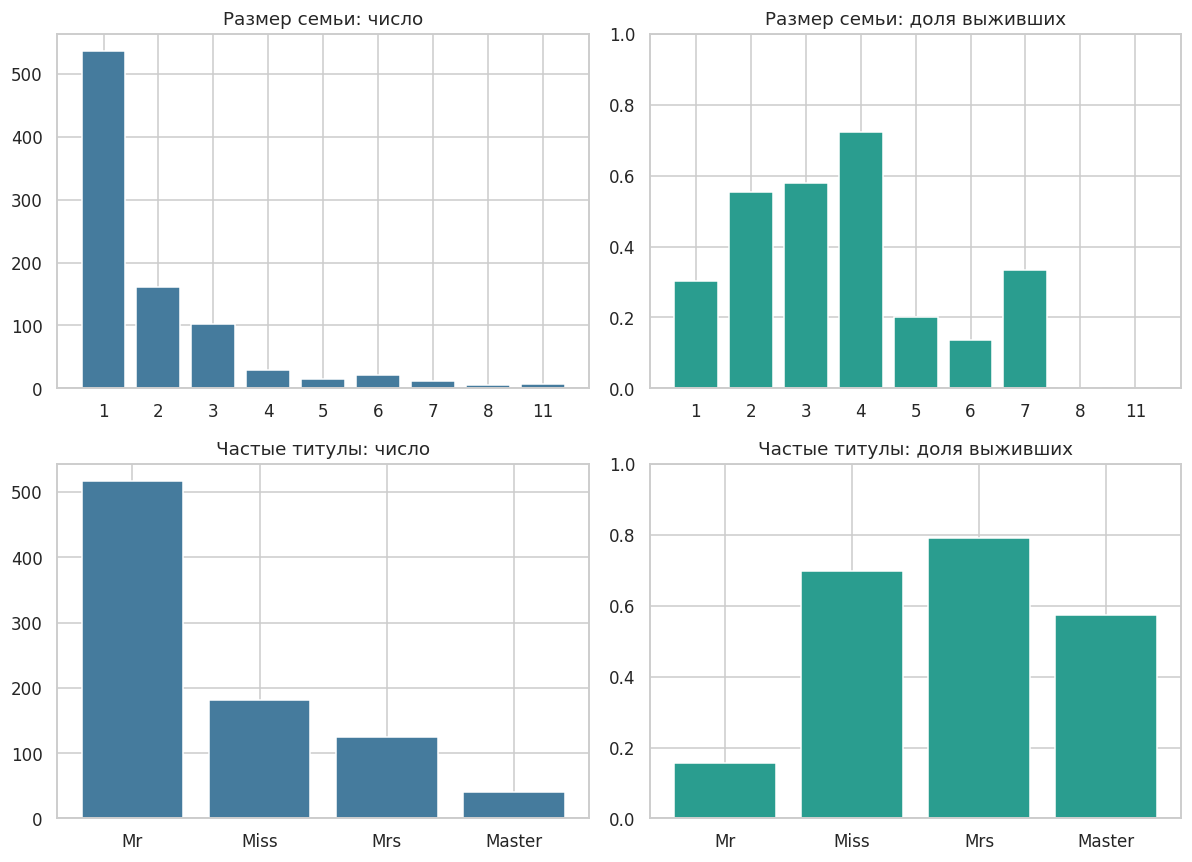

In [9]:
eda=train.assign(FamilySize=train.SibSp+train.Parch+1,
                 Title=train.Name.str.split(", ").str[1].str.split(".").str[0])
family=eda.groupby("FamilySize")["Survived"].agg(["size","mean"])
titles=eda.groupby("Title")["Survived"].agg(["size","mean"]).sort_values("size",ascending=False)
print("FamilySize:"); print(family.round(3).to_string())
print("Титулы:"); print(titles.head(10).round(3).to_string())
fig,axes=plt.subplots(2,2,figsize=(11,8))
axes[0,0].bar(family.index.astype(str),family["size"],color="#457b9d")
axes[0,0].set(title="Размер семьи: число")
axes[0,1].bar(family.index.astype(str),family["mean"],color="#2a9d8f")
axes[0,1].set(title="Размер семьи: доля выживших",ylim=(0,1))
common=titles.loc[titles["size"]>=10]
axes[1,0].bar(common.index,common["size"],color="#457b9d")
axes[1,0].set(title="Частые титулы: число")
axes[1,1].bar(common.index,common["mean"],color="#2a9d8f")
axes[1,1].set(title="Частые титулы: доля выживших",ylim=(0,1))
plt.tight_layout(); plt.show()


### Дополнительные кандидаты: `IsSingle`, группы титулов и бины возраста

`IsSingle` равен 1 для пассажира без родственников на борту. Среди одиночных пассажиров выжили **30,4%**, среди остальных — **50,6%**. Для известного `Age` доля выживших по квартилям находится примерно между **36%** и **46%**: связь не монотонна. Границы квартилей, как и порог частоты титулов, ниже рассчитаны на полном train **только для EDA**. При обучении модели они вычисляются внутри train-фолда. Бины `Fare` показаны в следующем разделе.


IsSingle:
          size   mean
IsSingle             
False      354  0.506
True       537  0.304
AgeBin (только известный Age):
                 size   mean
AgeBin                      
(0.419, 20.125]   179  0.458
(20.125, 28.0]    183  0.361
(28.0, 38.0]      175  0.434
(38.0, 80.0]      177  0.373
TitleGroup:
            size   mean
TitleGroup             
Mr           517  0.157
Miss         182  0.698
Mrs          125  0.792
Master        40  0.575
Misc          27  0.444


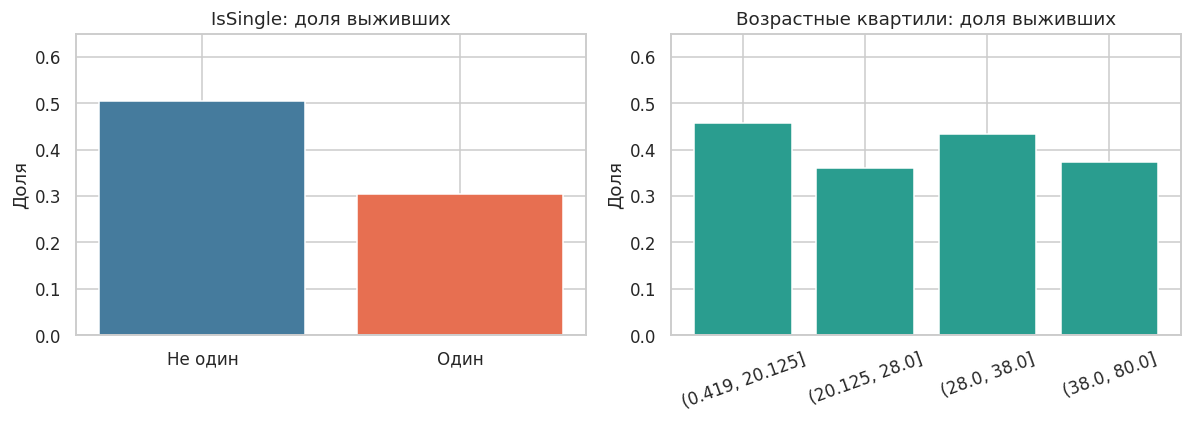

In [10]:
candidates = eda.copy()
candidates["IsSingle"] = candidates["FamilySize"].eq(1)
title_counts = candidates["Title"].value_counts()
candidates["TitleGroup"] = candidates["Title"].where(candidates["Title"].map(title_counts) >= 10, "Misc")
candidates["AgeBin"] = pd.qcut(candidates["Age"], 4, duplicates="drop")
single = candidates.groupby("IsSingle")["Survived"].agg(["size", "mean"])
age_bins = candidates.groupby("AgeBin", observed=True)["Survived"].agg(["size", "mean"])
title_groups = candidates.groupby("TitleGroup")["Survived"].agg(["size", "mean"]).sort_values("size", ascending=False)
print("IsSingle:")
print(single.round(3).to_string())
print("AgeBin (только известный Age):")
print(age_bins.round(3).to_string())
print("TitleGroup:")
print(title_groups.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Не один", "Один"], single["mean"], color=["#457b9d", "#e76f51"])
axes[0].set(title="IsSingle: доля выживших", ylabel="Доля", ylim=(0, .65))
axes[1].bar(range(len(age_bins)), age_bins["mean"], color="#2a9d8f")
axes[1].set_xticks(range(len(age_bins)), [str(v) for v in age_bins.index], rotation=20)
axes[1].set(title="Возрастные квартили: доля выживших", ylabel="Доля", ylim=(0, .65))
plt.tight_layout()
plt.show()


## 9. Fare и исход

В квартилях `Fare` доля выживших растёт от **19,7%** в нижнем до **58,1%** в верхнем. `Fare` связан с `Pclass` (**r ≈ −0,55**), поэтому эти доли не изолируют влияние цены. Бины здесь рассчитаны для EDA; в модели их границы нужно учить на train-фолде.


                 size   mean
FareQuartile                
(-0.001, 7.91]    223  0.197
(7.91, 14.454]    224  0.304
(14.454, 31.0]    222  0.455
(31.0, 512.329]   222  0.581


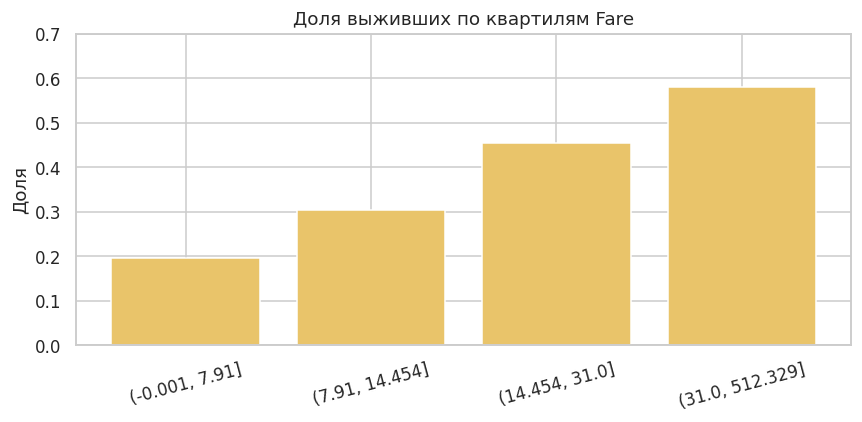

In [11]:
g=eda.assign(FareQuartile=pd.qcut(eda.Fare,4,duplicates="drop")).groupby("FareQuartile",observed=True)["Survived"].agg(["size","mean"])
print(g.round(3).to_string())
fig,ax=plt.subplots(figsize=(8,4))
ax.bar([str(v) for v in g.index],g["mean"],color="#e9c46a")
ax.set(title="Доля выживших по квартилям Fare",ylabel="Доля",ylim=(0,.7))
plt.xticks(rotation=15); plt.tight_layout(); plt.show()


## 10. Константы и корреляции

В train **нет константных столбцов** и среди основных полей нет признака, в котором одно значение занимает 95% строк. `FamilySize` связан с `SibSp` (**r = 0,89**) и `Parch` (**r = 0,78**) по определению. Его корреляция с `Survived` мала (**r = 0,02**), хотя график выше показывает нелинейную связь. Корреляции рассчитаны попарно по доступным значениям и не служат автоматическим критерием удаления признаков.


Константные столбцы: []
Поля с долей одного значения >=95%: []
Наибольшие доли одного значения: [('Cabin', np.float64(0.7710437710437711)), ('Parch', np.float64(0.7609427609427609)), ('Embarked', np.float64(0.7227833894500562))]
            Survived  Pclass    Age  SibSp  Parch   Fare  FamilySize
Survived       1.000  -0.338 -0.077 -0.035  0.082  0.257       0.017
Pclass        -0.338   1.000 -0.369  0.083  0.018 -0.549       0.066
Age           -0.077  -0.369  1.000 -0.308 -0.189  0.096      -0.302
SibSp         -0.035   0.083 -0.308  1.000  0.415  0.160       0.891
Parch          0.082   0.018 -0.189  0.415  1.000  0.216       0.783
Fare           0.257  -0.549  0.096  0.160  0.216  1.000       0.217
FamilySize     0.017   0.066 -0.302  0.891  0.783  0.217       1.000


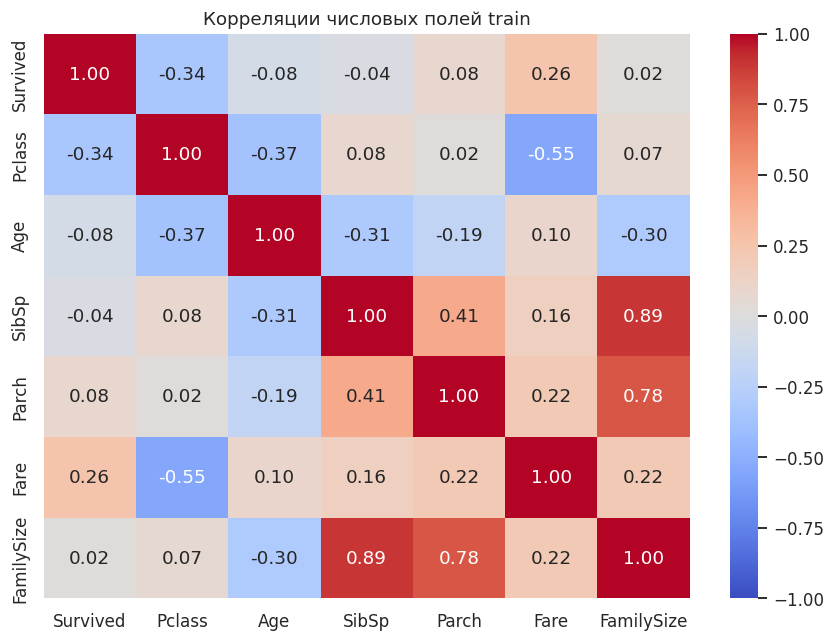

In [12]:
print("Константные столбцы:",[c for c in train if train[c].nunique(dropna=False)<=1])
main_cols=[c for c in train if c not in ["PassengerId","Name","Ticket","Survived"]]
dominant={c:train[c].value_counts(dropna=False,normalize=True).iloc[0] for c in main_cols}
print("Поля с долей одного значения >=95%:",[c for c,v in dominant.items() if v>=.95])
print("Наибольшие доли одного значения:",sorted(dominant.items(),key=lambda x:x[1],reverse=True)[:3])
cols=["Survived","Pclass","Age","SibSp","Parch","Fare","FamilySize"]
corr=eda[cols].corr(numeric_only=True)
print(corr.round(3).to_string())
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1,center=0,ax=ax)
ax.set(title="Корреляции числовых полей train")
plt.tight_layout(); plt.show()


## 11. Train и test

Доли пропусков `Age` и `Cabin` близки в train и test. Графики позволяют проверить сдвиг распределений основных полей без скрытых меток test. Локальная CV оценивает качество на train; Kaggle score появляется только после отправки предсказаний.


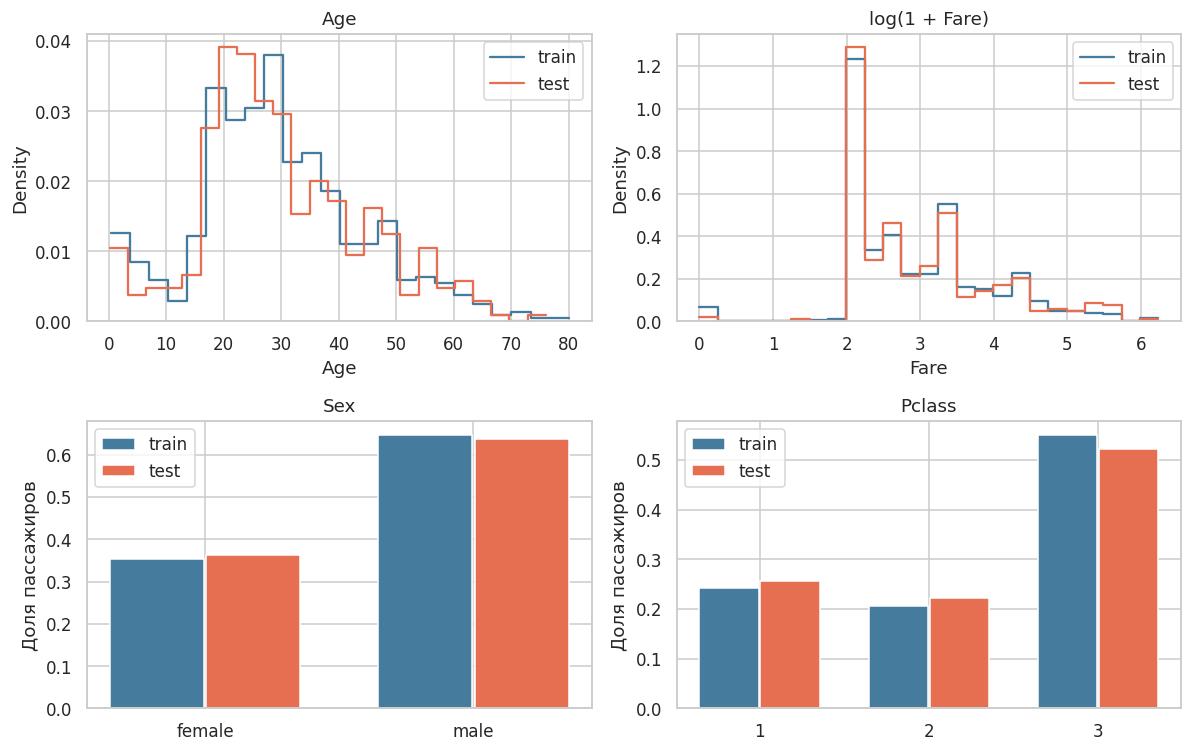

In [13]:
fig,axes=plt.subplots(2,2,figsize=(11,7))
for frame,label,color in [(train,"train","#457b9d"),(test,"test","#e76f51")]:
    sns.histplot(frame.Age.dropna(),bins=24,stat="density",element="step",fill=False,
                 ax=axes[0,0],color=color,label=label)
    sns.histplot(np.log1p(frame.Fare.dropna()),bins=25,stat="density",element="step",fill=False,
                 ax=axes[0,1],color=color,label=label)
for ax,col,order in [(axes[1,0],"Sex",["female","male"]),(axes[1,1],"Pclass",[1,2,3])]:
    x=np.arange(len(order))
    for offset,frame,label,color in [(-.18,train,"train","#457b9d"),(.18,test,"test","#e76f51")]:
        ax.bar(x+offset,frame[col].value_counts(normalize=True).reindex(order).fillna(0),
               width=.35,color=color,label=label)
    ax.set_xticks(x,[str(v) for v in order]); ax.set(title=col,ylabel="Доля пассажиров")
axes[0,0].set(title="Age"); axes[0,1].set(title="log(1 + Fare)")
for ax in axes.flat: ax.legend()
plt.tight_layout(); plt.show()


## Выводы для экспериментов

1. Сравнивать модели на одинаковых стратифицированных фолдах.
2. Проверить индикатор пропуска `Age` и способы заполнения внутри CV; отдельно оценить индикатор `Cabin`.
3. Менять по одному решению: `Title`, `FamilySize`, `Sex × Pclass`, преобразование `Fare`.
4. Не удалять наблюдения только потому, что они вышли за границы IQR.

План сравнений: [`research/features.md`](../research/features.md). Графики дают гипотезы; прирост F1 требует отдельной проверки.
